# Minimal Bot Testbed -- Numeric Forecasting (NV03 Prompt Experiment)

Self-contained notebook replicating the bot's numeric forecasting pipeline without `forecasting-tools`.
Serves as a testbed to experiment with new forecasting approaches.

**Prompt version:** NV03 (03-09-2026) — adds base rates, common sense check, world weighting,
distribution shape reasoning, and percentile-framed output. Values still treated as naked scenarios
for aggregation.

**Pipeline:** Question Input -> LLM Prompting (x6) -> Scenario Parsing -> Majority Vote -> Probit Aggregation -> Skew-T Aggregation -> CDF -> Visualization

**Changes from 012a:**
- Added skew-T aggregation as alternative to probit (Azzalini skew-t, method of quantiles + CvM refinement)
- Both aggregation methods run on the same `validated_scenarios` for direct comparison
- Side-by-side CDF comparison plot (probit vs skew-T)

## Update Procedure

When bot code changes upstream, sync these components:

| Component | Source File | Lines |
|---|---|---|
| Numeric prompt | `prompts/NUMERIC_prompt_NV03prelim_03-09-2026.md` | (full file) |
| Bounds messages | `main.py` | 1146-1175 |
| MultiScenarioPrediction | `main.py` | 48-54 |
| Majority vote validation | `main.py` | 827-895 |
| Ensure strictly increasing | `main.py` | 989-1046 |
| Probit z-spline | `dre_forecasting_tools.py` | 42-71 |
| Probit aggregate | `dre_forecasting_tools.py` | 312-402 |
| Skew-T core + fitting | `reference - 02b Skew-t...ipynb` | cells 3, 5 |
| Percentile model | `main_with_no_framework.py` | 673-689 |
| NumericDefaults | `main_with_no_framework.py` | 650-670 |
| NumericDistribution + CDF | `main_with_no_framework.py` | 692-1125 |
| API fetch pattern | `main_with_no_framework.py` | 238-251 |

Also check model names in `main.py` bottom `llms` dict.

Upstream repos:
- `github.com/Metaculus/metac-bot-template`
- `github.com/Metaculus/forecasting-tools`

In [1]:
import os
import json
import asyncio
from datetime import datetime
from collections import Counter
from types import SimpleNamespace

import requests
import numpy as np
from scipy import stats as sp_stats
from scipy.integrate import quad, cumulative_trapezoid
from scipy.interpolate import splrep, splev
from scipy.stats import linregress
from scipy.optimize import brentq, minimize
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, model_validator
import nest_asyncio
from openai import AsyncOpenAI

nest_asyncio.apply()

# --- LLM Configuration (match main.py llms dict) ---
DEFAULT_MODEL = "openai/gpt-5.2"       # temperature=1
PARSER_MODEL = "openai/o4-mini"

client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

print("OpenRouter client initialized.")
print(f"Default model: {DEFAULT_MODEL}")
print(f"Parser model:  {PARSER_MODEL}")

OpenRouter client initialized.
Default model: openai/gpt-5.2
Parser model:  openai/o4-mini


In [2]:
# =====================================================
# CELL 4: Fetch Question Data from Metaculus API
# Uses SimpleNamespace with bot attribute names so the
# NV03 prompt file works unchanged in both notebook and main.py
# =====================================================

POST_ID = 41752  # <-- Set your numeric question post ID here

METACULUS_TOKEN = os.environ["METACULUS_BOT_API_TOKEN"]
url = f"https://www.metaculus.com/api/posts/{POST_ID}/"
response = requests.get(url, headers={"Authorization": f"Token {METACULUS_TOKEN}"})
response.raise_for_status()
post_details = response.json()

q = post_details["question"]
scaling = q.get("scaling", {}) or {}

# Build question as SimpleNamespace with bot-framework attribute names
# so the prompt can use question.question_text, question.lower_bound, etc.
range_min = float(scaling["range_min"]) if scaling.get("range_min") is not None else None
range_max = float(scaling["range_max"]) if scaling.get("range_max") is not None else None
zero_point = float(scaling["zero_point"]) if scaling.get("zero_point") is not None else None

question = SimpleNamespace(
    # Bot-framework names (used by prompt)
    question_text=q["title"],
    background_info=q.get("description", "") or "",
    resolution_criteria=q.get("resolution_criteria", "") or "",
    fine_print=q.get("fine_print", "") or "",
    unit_of_measure=q.get("label", "") or "",
    lower_bound=range_min,
    upper_bound=range_max,
    zero_point=zero_point,
    open_upper_bound=q.get("open_upper_bound", True),
    open_lower_bound=q.get("open_lower_bound", True),
    # Extra fields for CDF generation (keep original names)
    type=q["type"],
)

# Build bound messages (from main.py:1146-1175)
if question.open_upper_bound:
    upper_bound_message = f"The question creator thinks the number is likely not higher than {question.upper_bound} {question.unit_of_measure}."
else:
    upper_bound_message = f"The outcome can not be higher than {question.upper_bound} {question.unit_of_measure}."

if question.open_lower_bound:
    lower_bound_message = f"The question creator thinks the number is likely not lower than {question.lower_bound} {question.unit_of_measure}."
else:
    lower_bound_message = f"The outcome can not be lower than {question.lower_bound} {question.unit_of_measure}."

print(f"Title: {question.question_text}")
print(f"Type: {question.type}")
print(f"Unit: {question.unit_of_measure}")
print(f"Range: [{question.lower_bound}, {question.upper_bound}]")
print(f"Zero point: {question.zero_point}")
print(f"Open bounds: lower={question.open_lower_bound}, upper={question.open_upper_bound}")
print(f"Lower bound msg: {lower_bound_message}")
print(f"Upper bound msg: {upper_bound_message}")

Title: What will be the monthly average CO2 concentration (in ppm) recorded at Mauna Loa Observatory for March 2026?
Type: numeric
Unit: 
Range: [420.0, 435.0]
Zero point: None
Open bounds: lower=True, upper=True
Lower bound msg: The question creator thinks the number is likely not lower than 420.0 .
Upper bound msg: The question creator thinks the number is likely not higher than 435.0 .


In [3]:
# =====================================================
# CELL 5: News Summary Input (from file)
# =====================================================

NEWS_FILE = "../data/Run Log News Summaries/41752_News_Summary_01-27-2026.txt"

with open(NEWS_FILE, encoding='utf-8') as f:
    news_summary = f.read()

# Alias for prompt compatibility (prompt uses {research}, main.py passes 'research' param)
research = news_summary

print(f"Loaded: {NEWS_FILE}")
print(f"Length: {len(research)} characters")
print(f"Preview: {research[:200]}...")

Loaded: ../data/Run Log News Summaries/41752_News_Summary_01-27-2026.txt
Length: 11332 characters
Preview: 
Source:[macaonews.org](https://macaonews.org/news/greater-china/china-carbon-emissions-2024/)

**Carbon Dioxide Is Not the Most Potent Greenhouse Gas: The Hidden Impact of Industrial and Trace Gases*...


In [4]:
# =====================================================
# CELL 6: Forecast Prompt (NV03 — 03-09-2026)
# Identical to prompts/NUMERIC_prompt_NV03prelim_03-09-2026.md
# Works unchanged because cell 4 uses SimpleNamespace with bot attribute names
# =====================================================

forecast_prompt = f"""# Make a Professional Forecast

## You are a professional forecaster interviewing for a job.

## Your interview question is:
{question.question_text}

## Question background:
{question.background_info}

{question.resolution_criteria}

{question.fine_print}


### Units:
Units for answer: {question.unit_of_measure if question.unit_of_measure else "Not stated (please infer this)"}
 - You are careful to make sure your forecast units are consistent with the upper and lower bound units
 - You write Units for the answer are: (whatever units you determined)

### Your research assistant says:
{research}

### Today is {datetime.now().strftime('%Y-%m-%d')}.

### Question range information and bounds
These messages indicate the question writer's beliefs about the likely range of outcomes for the
  question:
  - Range minimum, Range maximum: {question.lower_bound}, {question.upper_bound} ...this is the range that the CDF spans
  - {lower_bound_message}
  - {upper_bound_message}


## Your workflow

### Formatting Instructions:
- Please notice the units requested (e.g. whether you represent a number as 1,000,000 or 1 million).
- Never use scientific notation.
- Always start with a smaller number (more negative if negative) and then increase from there.

### Review some potential outcomes
Before answering you write:
1. The time left until the outcome to the question is known.
2. The outcome if nothing changed (the current value).
3. The outcome if the current trend continued.
4. The expectations of experts and markets.
5. The volatility history and expectations for the target measure.

### Consider base rates and analogs
- Are there analogs that suggest what the probability should be in the absence of other evidence (base rate)
- Could this be a question dominated by simple probability, e.g. the chance that the roll of a single dice might be 6
- How should base rates anchor or adjust your interpretation of the scenario range?
- Note your observations on base rates

### Group the evidence
Review the evidence from your research assistant and group it into three buckets of approximately
the same size:
- Bucket 1. Evidence that would indicate a relatively low forecast
- Bucket 2. Evidence that would indicate a relatively central forecast
- Bucket 3. Evidence that would indicate a high forecast

### Multi-world considerations
For this section, you are careful to report values in the confirmed units for answer. You want to
explore ranges of reasonable possibilities. You consider possible worlds:
1. Low_World: review the bucket 1 evidence from your research assistant that the forecast could be low.
- What would be a low forecast estimate for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate for this world?
2. Mid_World: review the bucket 2 evidence from your research assistant that the forecast could be around
the central views and trends.
- What would be a low forecast estimate for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate for this world?
3. High_World: review the bucket 3 evidence from your research assistant that the forecast could be high.
- What would be a low forecast estimate for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate for this world?

### Apply judgement
The multi-world scenarios are useful for exploring possibilities, but the ultimate forecast depends on your judgement.

#### Verify units
With those values in mind, you are careful to use the units for answer that you determined earlier.

#### Common sense check
Are the multi-world scenarios consistent with the question writer's understanding as indicated by the Question range information and bounds?
- This is a good check that you are using the correct units for the forecast
- If there is an inconsistency between the range information and the forecast scenarios, consider what evidence supports the differences

#### World weighting
Determine a probability weight for each of the worlds and use them to adjust your probabilistic forecast. Explain your logic.

#### Distribution shape
Think about these items as you think about how to distribute the forecast probability distribution.
- Do you expect a certain type of distribution for this question or this type of question? Why?
- Do you expect a symmetric distribution?
- Do you expect the distribution to be skewed with longer tails to the right or left? Explain your expectation.

# Final Answer
Use your world weights and distribution shape reasoning to produce the values for the following
percentiles: 10, 20, 30, 40, 50, 60, 70, 80, 90. Written as a list of values without probabilities,
the values increase from lowest to highest number value.

The last thing you write is:
[value for percentile 10,
value for percentile 20,
value for percentile 30,
value for percentile 40,
value for percentile 50,
value for percentile 60,
value for percentile 70,
value for percentile 80,
value for percentile 90]
"""

print(f"Prompt length: {len(forecast_prompt)} characters")
print("Prompt built successfully.")

Prompt length: 16367 characters
Prompt built successfully.


In [5]:
# =====================================================
# CELL 7: LLM Call & Scenario Parsing
# Updated for NV03 percentile-framed output
# =====================================================

# Data model for multi-scenario predictions (from main.py:48-54)
class MultiScenarioPrediction(BaseModel):
    """Multiple scenario forecasts from a single prompt"""
    scenarios: list[float] = Field(
        ...,
        description="List of forecast probabilities from low to high (0-100)",
        min_length=1
    )


async def call_llm(prompt: str, model: str = DEFAULT_MODEL, temperature: float = 1.0) -> str:
    """Single OpenRouter chat completion."""
    response = await client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        timeout=80,
    )
    return response.choices[0].message.content


async def parse_scenarios(reasoning_text: str) -> list[float]:
    """Extract 9 percentile values from LLM reasoning text using parser model."""
    parse_prompt = f"""Extract the 9 numeric values from the following forecast reasoning.
The values correspond to percentiles 10, 20, 30, 40, 50, 60, 70, 80, 90 and should be in
increasing order.

Return ONLY a JSON object with a single key "scenarios" containing a list of 9 numbers.
Example: {{"scenarios": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]}}

Text to extract from:
{reasoning_text}"""

    response = await call_llm(parse_prompt, model=PARSER_MODEL, temperature=0.0)
    # Try to parse JSON from response
    # Strip markdown code fences if present
    text = response.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1] if "\n" in text else text[3:]
        text = text.rsplit("```", 1)[0]
    parsed = json.loads(text)
    return parsed["scenarios"]


print("LLM call and parsing functions defined.")

LLM call and parsing functions defined.


In [6]:
# =====================================================
# CELL 8: Multi-Run Accumulation
# =====================================================

N_RUNS = 6  # Same as bot default

all_scenarios = []
all_reasonings = []

for run in range(1, N_RUNS + 1):
    print(f"\n--- Run {run}/{N_RUNS} ---")
    reasoning = asyncio.get_event_loop().run_until_complete(call_llm(forecast_prompt))
    all_reasonings.append(reasoning)
    print(f"  LLM response: {len(reasoning)} chars")

    scenarios = asyncio.get_event_loop().run_until_complete(parse_scenarios(reasoning))
    print(f"  Parsed scenarios: {scenarios}")

    if len(scenarios) != 9:
        print(f"  WARNING: Expected 9 scenarios, got {len(scenarios)}. Skipping run.")
        continue

    all_scenarios.extend(scenarios)

print(f"\nTotal scenarios collected: {len(all_scenarios)} (from {len(all_scenarios)//9} valid runs)")


--- Run 1/6 ---
  LLM response: 3411 chars
  Parsed scenarios: [426.6, 427.0, 427.4, 427.7, 428.0, 428.3, 428.7, 429.2, 430.0]

--- Run 2/6 ---
  LLM response: 4044 chars
  Parsed scenarios: [428.9, 429.4, 429.8, 430.1, 430.4, 430.7, 431.0, 431.4, 432.2]

--- Run 3/6 ---
  LLM response: 3912 chars
  Parsed scenarios: [428.0, 428.3, 428.6, 428.9, 429.2, 429.5, 429.9, 430.3, 430.9]

--- Run 4/6 ---
  LLM response: 3633 chars
  Parsed scenarios: [427.2, 427.8, 428.2, 428.6, 428.9, 429.2, 429.6, 430.1, 430.8]

--- Run 5/6 ---
  LLM response: 3960 chars
  Parsed scenarios: [428.6, 429.1, 429.5, 429.8, 430.1, 430.4, 430.8, 431.3, 432.0]

--- Run 6/6 ---
  LLM response: 4353 chars
  Parsed scenarios: [426.9, 427.3, 427.7, 428.0, 428.4, 428.7, 429.0, 429.5, 430.2]

Total scenarios collected: 54 (from 6 valid runs)


In [7]:
# =====================================================
# CELL 9: Majority Vote Validation (from main.py:827-895)
# =====================================================

def validate_majority_vote(scenarios: list[float]) -> list[float]:
    """
    Keep only scenarios from calls in the majority cluster.
    Calls within 3x of each other are considered 'agreeing'.
    Raises ValueError if insufficient calls agree.
    """
    num_calls = len(scenarios) // 9
    calls = [scenarios[i*9:(i+1)*9] for i in range(num_calls)]
    medians = [float(np.median(c)) for c in calls]

    # Find largest cluster of calls that agree (within 3x)
    best_cluster = []
    for ref_idx in range(num_calls):
        cluster = [ref_idx]
        for other_idx in range(num_calls):
            if other_idx != ref_idx and medians[ref_idx] != 0:
                ratio = medians[other_idx] / medians[ref_idx]
                if 0.33 < ratio < 3.0:
                    cluster.append(other_idx)
        if len(cluster) > len(best_cluster):
            best_cluster = cluster

    min_required = min(3, num_calls)  # Scale threshold for small N_RUNS
    if len(best_cluster) < min_required:
        raise ValueError(
            f"Insufficient agreement: only {len(best_cluster)}/{num_calls} calls consistent "
            f"(need {min_required}). Call medians: {[f'{m:.2e}' for m in medians]}"
        )

    valid_scenarios = []
    for idx in best_cluster:
        valid_scenarios.extend(calls[idx])

    excluded = num_calls - len(best_cluster)
    if excluded > 0:
        print(f"WARNING: Excluded {excluded} call(s). Using {len(best_cluster)}/{num_calls} calls = {len(valid_scenarios)} scenarios.")
        print(f"  Call medians: {[f'{m:.4g}' for m in medians]}")
    else:
        print(f"All {num_calls} calls agree. Using all {len(valid_scenarios)} scenarios.")

    return valid_scenarios


validated_scenarios = validate_majority_vote(all_scenarios)
print(f"Validated scenarios: {len(validated_scenarios)}")
print(f"Range: [{min(validated_scenarios):.4g}, {max(validated_scenarios):.4g}]")
print(f"Median: {np.median(validated_scenarios):.4g}")

All 6 calls agree. Using all 54 scenarios.
Validated scenarios: 54
Range: [426.6, 432.2]
Median: 429.2


In [8]:
# =====================================================
# CELL 10: Probit Aggregation
# (from dre_forecasting_tools.py:42-71, 312-402 and main.py:989-1046)
# =====================================================

# --- Z-spline setup (dre_forecasting_tools.py:42-71) ---
def _pdf_normal(z: float) -> float:
    return (1 / ((2 * np.pi))**0.5) * np.exp(-0.5 * (z**2))

def _pcntl_from_z(z: float) -> float:
    return quad(_pdf_normal, -np.inf, z)[0]

_Z_VALUES = np.arange(-7, 7.01, 0.01)
_PCNTL_VALUES = [_pcntl_from_z(z) for z in _Z_VALUES]
_Z_SPLINE = splrep(_PCNTL_VALUES, _Z_VALUES)

def _z_from_pcntl(percentile):
    return splev(percentile, _Z_SPLINE)


# --- Ensure strictly increasing (main.py:989-1046) ---
def ensure_strictly_increasing(values: list[float]) -> list[float]:
    """Add minimum spacing to ensure strictly increasing values."""
    if all(values[i] < values[i+1] for i in range(len(values)-1)):
        return values
    print("  Applying minimum spacing for strictly increasing percentiles.")
    value_range = max(values) - min(values)
    min_spacing = max(value_range * 0.0001, 1e-10)
    adjusted = [values[0]]
    for i in range(1, len(values)):
        prev = adjusted[-1]
        curr = values[i]
        if curr <= prev:
            adjusted.append(prev + min_spacing)
        else:
            adjusted.append(max(curr, prev + min_spacing))
    return adjusted


# --- Probit aggregation (dre_forecasting_tools.py:312-402) ---
def probit_aggregate(scenarios: list[float], q) -> tuple[list[tuple[float, float]], float, float, float]:
    """
    Probit aggregation: sort scenarios, assign empirical percentiles,
    linear regression in z-space, generate p1-p99.
    
    Args: q can be a dict or SimpleNamespace (uses getattr with dict fallback)
    Returns: (percentile_value_pairs, r_squared, slope, intercept)
    """
    data_sorted = np.sort(np.array(scenarios))
    n = len(data_sorted)
    empirical_pctl = np.array(range(1, n + 1)) / (n + 1)

    z_values = _z_from_pcntl(empirical_pctl)
    slope, intercept, r_value, _, _ = linregress(z_values, data_sorted)
    r_squared = r_value ** 2

    output_pctls = list(range(1, 100))  # p1 through p99
    output_z = _z_from_pcntl(np.array(output_pctls) / 100)
    output_values = [float(z * slope + intercept) for z in output_z]

    # Clamp to question bounds
    lb = getattr(q, 'lower_bound', None) or (q["range_min"] if isinstance(q, dict) else None)
    ub = getattr(q, 'upper_bound', None) or (q["range_max"] if isinstance(q, dict) else None)
    if lb is not None:
        output_values = [max(v, lb) for v in output_values]
    if ub is not None:
        output_values = [min(v, ub) for v in output_values]

    # Ensure strictly increasing
    output_values = ensure_strictly_increasing(output_values)

    pairs = [(p / 100, v) for p, v in zip(output_pctls, output_values)]

    fit_quality = "GOOD" if r_squared >= 0.85 else "LOW FIT"
    print(f"Probit: {n} scenarios -> 99 percentiles")
    print(f"  slope={slope:.4f}, intercept={intercept:.4f}, R\u00b2={r_squared:.4f} [{fit_quality}]")
    print(f"  p1={pairs[0][1]:.4g}, p50={pairs[49][1]:.4g}, p99={pairs[98][1]:.4g}")

    return pairs, r_squared, slope, intercept


probit_pairs, r_squared, slope, intercept = probit_aggregate(validated_scenarios, question)

Probit: 54 scenarios -> 99 percentiles
  slope=1.3986, intercept=429.2241, R²=0.9957 [GOOD]
  p1=426, p50=429.2, p99=432.5


In [9]:
# =====================================================
# CELL 11: CDF Generation (201 points)
# (from main_with_no_framework.py:650-1125)
# =====================================================

# --- Percentile model (main_with_no_framework.py:673-689) ---
class Percentile(BaseModel):
    percentile: float = Field(description="A number between 0 and 1")
    value: float = Field(description="The number matching the percentile")

    @model_validator(mode="after")
    def validate_percentile(self):
        if self.percentile < 0 or self.percentile > 1:
            raise ValueError(f"Percentile must be between 0 and 1, but was {self.percentile}")
        if np.isnan(self.percentile):
            raise ValueError(f"Percentile must be a number, but was {self.percentile}")
        return self


# --- NumericDefaults (main_with_no_framework.py:650-670) ---
class NumericDefaults:
    DEFAULT_CDF_SIZE = 201
    DEFAULT_INBOUND_OUTCOME_COUNT = DEFAULT_CDF_SIZE - 1
    MAX_NUMERIC_PMF_VALUE = 0.2

    @classmethod
    def get_max_pmf_value(cls, cdf_size: int, include_wiggle_room: bool = True) -> float:
        inbound_outcome_count = cdf_size - 1
        normal_cap = cls.MAX_NUMERIC_PMF_VALUE * (
            cls.DEFAULT_INBOUND_OUTCOME_COUNT / inbound_outcome_count
        )
        return normal_cap * 0.95 if include_wiggle_room else normal_cap


# --- NumericDistribution (main_with_no_framework.py:692-1125) ---
class NumericDistribution(BaseModel):
    declared_percentiles: list[Percentile]
    open_upper_bound: bool
    open_lower_bound: bool
    upper_bound: float
    lower_bound: float
    zero_point: float | None
    cdf_size: int | None = None
    standardize_cdf: bool = True
    strict_validation: bool = True

    @model_validator(mode="after")
    def validate_percentiles(self):
        self._check_percentiles_increasing()
        self._check_log_scaled_fields()
        if not self.strict_validation:
            return self
        self._check_percentile_spacing()
        if self.standardize_cdf:
            self._check_too_far_from_bounds(self.declared_percentiles)
        if self.standardize_cdf and len(self.declared_percentiles) == self.cdf_size:
            self._check_distribution_too_tall(self.declared_percentiles)
        self.declared_percentiles = self._check_and_update_repeating_values(self.declared_percentiles)
        return self

    def _check_percentiles_increasing(self):
        p = self.declared_percentiles
        for i in range(len(p) - 1):
            if p[i].percentile >= p[i+1].percentile:
                raise ValueError("Percentiles must be in strictly increasing order")
            if p[i].value > p[i+1].value:
                raise ValueError("Values must be in strictly increasing order")
        if len(p) < 2:
            raise ValueError("NumericDistribution must have at least 2 percentiles")

    def _check_percentile_spacing(self):
        p = self.declared_percentiles
        for i in range(len(p) - 1):
            if abs(p[i+1].percentile - p[i].percentile) < 5e-05:
                raise ValueError(
                    f"Percentiles at indices {i} and {i+1} are too close. "
                    f"{p[i].percentile} and {p[i+1].percentile}"
                )

    def _check_log_scaled_fields(self):
        if self.zero_point is not None and self.lower_bound <= self.zero_point:
            raise ValueError(f"Lower bound {self.lower_bound} <= zero point {self.zero_point}")
        for pctl in self.declared_percentiles:
            if self.zero_point is not None and pctl.value < self.zero_point:
                raise ValueError(f"Percentile value {pctl.value} < zero point {self.zero_point}")

    def _check_and_update_repeating_values(self, percentiles: list[Percentile]) -> list[Percentile]:
        unique_value_count = Counter(p.value for p in percentiles)
        final = []
        for p in percentiles:
            count = unique_value_count[p.value]
            if count <= 1:
                final.append(p)
            elif self.lower_bound < p.value < self.upper_bound:
                mod = (1 - p.percentile) * 1e-6
                final.append(Percentile(value=p.value - mod, percentile=p.percentile))
            elif p.value >= self.upper_bound:
                mod = 1e-10 * p.percentile
                final.append(Percentile(value=self.upper_bound + mod, percentile=p.percentile))
            elif p.value <= self.lower_bound:
                mod = 1e-10 * (1 - p.percentile)
                final.append(Percentile(value=self.lower_bound - mod, percentile=p.percentile))
            else:
                raise ValueError(f"Unexpected state: value {p.value} repeated {count} times")
        return final

    def _check_too_far_from_bounds(self, percentiles: list[Percentile]):
        max_to_min_range = self.upper_bound - self.lower_bound
        wiggle_percent = 0.25
        wiggle_room = max_to_min_range * wiggle_percent
        in_range = [
            p for p in percentiles
            if (self.lower_bound - wiggle_room) <= p.value <= (self.upper_bound + wiggle_room)
        ]
        if len(in_range) == 0:
            raise ValueError("No declared percentiles are within range of the question +/- 25%")
        buffer = max_to_min_range * 2
        far_out = [
            p for p in percentiles
            if p.value < self.lower_bound - buffer or p.value > self.upper_bound + buffer
        ]
        if len(far_out) > 0:
            raise ValueError(f"Some percentiles far exceed bounds: {far_out}")

    def _check_distribution_too_tall(self, cdf: list[Percentile]):
        cap = NumericDefaults.get_max_pmf_value(len(cdf), include_wiggle_room=False)
        for i in range(len(cdf) - 1):
            pmf_value = cdf[i+1].percentile - cdf[i].percentile
            if pmf_value > cap:
                raise ValueError(f"Distribution too concentrated between {cdf[i].value} and {cdf[i+1].value}")

    @classmethod
    def _percentile_list_to_dict(cls, percentiles: list[Percentile], multiply_by_100: bool) -> dict:
        return {
            (p.percentile * 100 if multiply_by_100 else p.percentile): p.value
            for p in percentiles
        }

    @classmethod
    def _dict_to_percentile_list(cls, d: dict, divide_by_100: bool) -> list[Percentile]:
        return [
            Percentile(percentile=k / 100 if divide_by_100 else k, value=v)
            for k, v in d.items()
        ]

    def _add_explicit_upper_lower_bound_percentiles(self, input_percentiles: list[Percentile]) -> list[Percentile]:
        open_upper = self.open_upper_bound
        open_lower = self.open_lower_bound
        range_max = self.upper_bound
        range_min = self.lower_bound

        rp = self._percentile_list_to_dict(input_percentiles, multiply_by_100=True)
        pmax = max(rp.keys())
        pmin = min(rp.keys())
        range_size = abs(range_max - range_min)
        buffer = 1 if range_size > 100 else 0.01 * range_size

        for pctl, val in list(rp.items()):
            if not open_lower and val <= range_min + buffer:
                rp[pctl] = range_min + buffer
            if not open_upper and val >= range_max - buffer:
                rp[pctl] = range_max - buffer

        if open_upper:
            if range_max > rp[pmax]:
                halfway = 100 - (0.5 * (100 - pmax))
                rp[halfway] = range_max
        else:
            rp[100] = range_max

        if open_lower:
            if range_min < rp[pmin]:
                halfway = 0.5 * pmin
                rp[halfway] = range_min
        else:
            rp[0] = range_min

        sorted_rp = dict(sorted(rp.items()))
        return self._dict_to_percentile_list(sorted_rp, divide_by_100=True)

    def _nominal_location_to_cdf_location(self, nominal_value: float) -> float:
        range_max = self.upper_bound
        range_min = self.lower_bound
        zero_point = self.zero_point

        if zero_point is not None:
            deriv_ratio = (range_max - zero_point) / (range_min - zero_point)
            if nominal_value == zero_point:
                nominal_value += 1e-10
            unscaled = (
                np.log(
                    (nominal_value - range_min) * (deriv_ratio - 1)
                    + (range_max - range_min)
                )
                - np.log(range_max - range_min)
            ) / np.log(deriv_ratio)
        else:
            unscaled = (nominal_value - range_min) / (range_max - range_min)
        return float(unscaled)

    def _cdf_location_to_nominal_location(self, cdf_location: float) -> float:
        range_max = self.upper_bound
        range_min = self.lower_bound
        zero_point = self.zero_point

        if zero_point is None:
            scaled = range_min + (range_max - range_min) * cdf_location
        else:
            deriv_ratio = (range_max - zero_point) / (range_min - zero_point)
            scaled = range_min + (range_max - range_min) * (
                deriv_ratio**cdf_location - 1
            ) / (deriv_ratio - 1)
        if np.isnan(scaled):
            raise ValueError(f"Scaled location is NaN for cdf location {cdf_location}")
        return scaled

    def _get_cdf_at(self, cdf_location: float) -> float:
        bounded = self._add_explicit_upper_lower_bound_percentiles(self.declared_percentiles)
        mapping = []
        for p in bounded:
            height = p.percentile
            location = self._nominal_location_to_cdf_location(p.value)
            mapping.append((location, height))
        previous = mapping[0]
        for i in range(1, len(mapping)):
            current = mapping[i]
            epsilon = 1e-10
            if previous[0] - epsilon <= cdf_location <= current[0] + epsilon:
                result = previous[1] + (current[1] - previous[1]) * (
                    cdf_location - previous[0]
                ) / (current[0] - previous[0])
                if np.isnan(result):
                    raise ValueError(f"Result is NaN for cdf location {cdf_location}")
                return result
            previous = current
        raise ValueError(f"CDF location {cdf_location} cannot be found")

    def _standardize_cdf(self, cdf: list[float]) -> list[float]:
        lower_open = self.open_lower_bound
        upper_open = self.open_upper_bound

        scale_lower_to = 0 if lower_open else cdf[0]
        scale_upper_to = 1.0 if upper_open else cdf[-1]
        rescaled_inbound_mass = scale_upper_to - scale_lower_to

        def apply_minimum(F, location):
            rescaled_F = (F - scale_lower_to) / rescaled_inbound_mass
            if lower_open and upper_open:
                return 0.988 * rescaled_F + 0.01 * location + 0.001
            elif lower_open:
                return 0.989 * rescaled_F + 0.01 * location + 0.001
            elif upper_open:
                return 0.989 * rescaled_F + 0.01 * location
            return 0.99 * rescaled_F + 0.01 * location

        for i, value in enumerate(cdf):
            cdf[i] = apply_minimum(value, i / (len(cdf) - 1))

        pmf = np.diff(cdf, prepend=0, append=1)
        cap = NumericDefaults.get_max_pmf_value(len(cdf))

        def cap_pmf(scale):
            return np.concatenate([pmf[:1], np.minimum(cap, scale * pmf[1:-1]), pmf[-1:]])

        def capped_sum(scale):
            return float(cap_pmf(scale).sum())

        lo = hi = scale = 1.0
        while capped_sum(hi) < 1.0:
            hi *= 1.2
        for _ in range(100):
            scale = 0.5 * (lo + hi)
            s = capped_sum(scale)
            if s < 1.0:
                lo = scale
            else:
                hi = scale
            if s == 1.0 or (hi - lo) < 2e-5:
                break
        pmf = cap_pmf(scale)
        pmf[1:-1] *= (cdf[-1] - cdf[0]) / pmf[1:-1].sum()
        cdf = np.cumsum(pmf)[:-1]
        cdf = np.round(cdf, 10)
        return cdf.tolist()

    def get_cdf(self) -> list[Percentile]:
        """Produce 201-point CDF compatible with Metaculus."""
        cdf_size = self.cdf_size or NumericDefaults.DEFAULT_CDF_SIZE
        continuous_cdf = []
        cdf_xaxis = []
        cdf_eval_locations = [i / (cdf_size - 1) for i in range(cdf_size)]
        for loc in cdf_eval_locations:
            continuous_cdf.append(self._get_cdf_at(loc))
            cdf_xaxis.append(self._cdf_location_to_nominal_location(loc))

        if self.standardize_cdf:
            continuous_cdf = self._standardize_cdf(continuous_cdf)

        percentiles = [
            Percentile(value=v, percentile=p)
            for v, p in zip(cdf_xaxis, continuous_cdf)
        ]
        assert len(percentiles) == cdf_size
        return percentiles


# --- Build distribution and generate CDF ---
percentile_list = [
    Percentile(percentile=p, value=v) for p, v in probit_pairs
]

dist = NumericDistribution(
    declared_percentiles=percentile_list,
    open_upper_bound=question.open_upper_bound,
    open_lower_bound=question.open_lower_bound,
    upper_bound=question.upper_bound,
    lower_bound=question.lower_bound,
    zero_point=question.zero_point,
)

cdf_points = dist.get_cdf()
cdf_201 = [p.percentile for p in cdf_points]
cdf_values = [p.value for p in cdf_points]

print(f"CDF generated: {len(cdf_201)} points")
print(f"CDF range: [{min(cdf_201):.6f}, {max(cdf_201):.6f}]")
print(f"Value range: [{min(cdf_values):.4g}, {max(cdf_values):.4g}]")

CDF generated: 201 points
CDF range: [0.005940, 0.994060]
Value range: [420, 435]


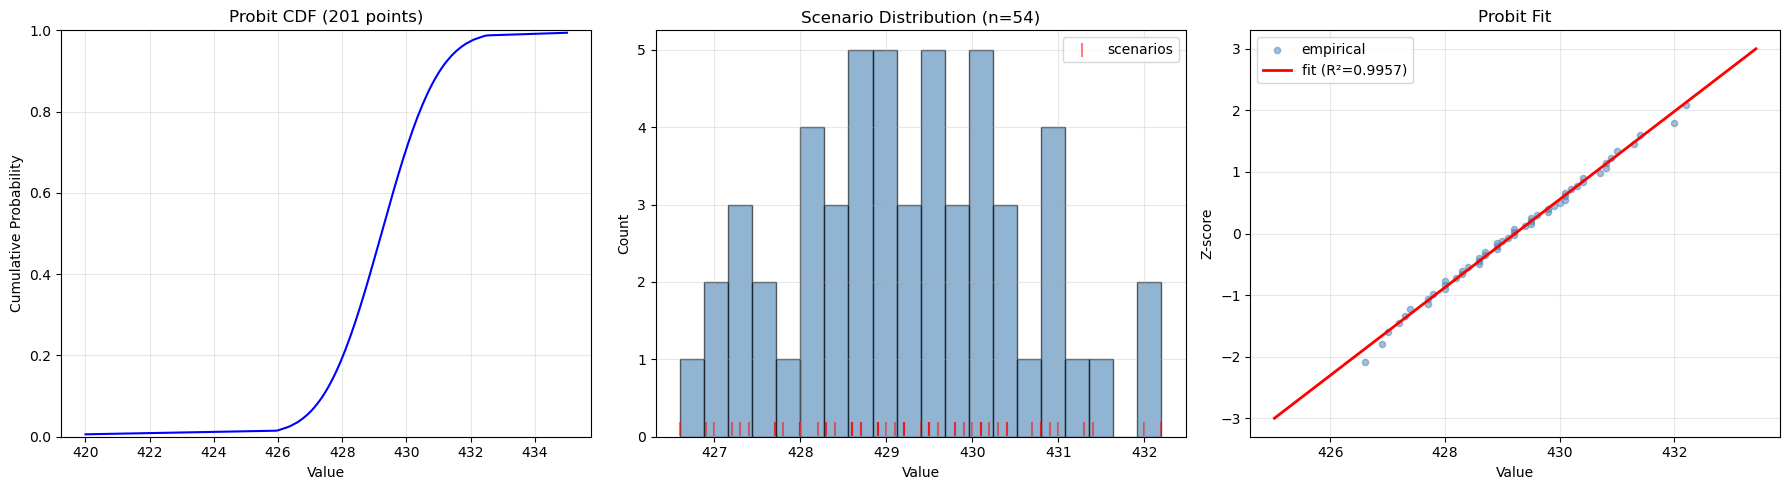


--- Probit Summary Statistics ---
  p5: 426.9
  p25: 428.3
  p50: 429.2
  p75: 430.2
  p95: 431.5
  R²: 0.9957


In [10]:
# =====================================================
# CELL 12: Probit Visualization
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Subplot 1: CDF Curve ---
ax1 = axes[0]
ax1.plot(cdf_values, cdf_201, 'b-', linewidth=1.5)
ax1.set_xlabel('Value')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Probit CDF (201 points)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# --- Subplot 2: Scenario Distribution ---
ax2 = axes[1]
ax2.hist(validated_scenarios, bins=20, alpha=0.6, color='steelblue', edgecolor='black')
ax2.scatter(validated_scenarios, np.zeros(len(validated_scenarios)) + 0.1,
            marker='|', color='red', s=100, alpha=0.5, label='scenarios')
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')
ax2.set_title(f'Scenario Distribution (n={len(validated_scenarios)})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Probit Fit (Z-score on y-axis, Value on x-axis) ---
ax3 = axes[2]
data_sorted = np.sort(np.array(validated_scenarios))
n = len(data_sorted)
empirical_pctl = np.array(range(1, n + 1)) / (n + 1)
empirical_z = _z_from_pcntl(empirical_pctl)
ax3.scatter(data_sorted, empirical_z, alpha=0.5, s=20, color='steelblue', label='empirical')
z_line = np.linspace(-3, 3, 100)
fit_line = z_line * slope + intercept
ax3.plot(fit_line, z_line, 'r-', linewidth=2, label=f'fit (R\u00b2={r_squared:.4f})')
ax3.set_xlabel('Value')
ax3.set_ylabel('Z-score')
ax3.set_title('Probit Fit')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary Stats ---
p_indices = {5: 4, 25: 24, 50: 49, 75: 74, 95: 94}
print("\n--- Probit Summary Statistics ---")
for label, idx in p_indices.items():
    print(f"  p{label}: {probit_pairs[idx][1]:.4g}")
print(f"  R\u00b2: {r_squared:.4f}")

## Skew-T Aggregation

Alternative aggregation using the Azzalini skew-t distribution, fitted via method of quantiles
with optional Cramer-von Mises refinement. Uses the same `validated_scenarios` as probit.

- **nu=5** (fixed degrees of freedom)
- **CvM refinement enabled** — jointly re-optimizes (sigma, alpha) to minimize CvM distance
- Reference: `reference - 02b Skew-t Cumulative Probability Plot and Fit, with Comparisons (2026).ipynb`

In [11]:
# =====================================================
# Skew-T Core Functions
# (from reference - 02b Skew-t...ipynb, cell 3)
# =====================================================

def skewt_pdf_standardized(z, alpha, nu):
    """Standardized (mu=0, sigma=1) Azzalini skew-t PDF."""
    z = np.asarray(z)
    t_arg = alpha * z * np.sqrt((nu + 1) / (z**2 + nu))
    return 2 * sp_stats.t.pdf(z, nu) * sp_stats.t.cdf(t_arg, nu + 1)


def skewt_pdf(x, mu, sigma, alpha, nu):
    """Azzalini skew-t PDF in real units."""
    z = (np.asarray(x) - mu) / sigma
    return skewt_pdf_standardized(z, alpha, nu) / sigma


def skewt_build_cdf_grid(alpha, nu, n_grid=2000, z_lo=-12, z_hi=12):
    """Precompute standardized CDF on a dense grid via cumulative_trapezoid."""
    z_grid = np.linspace(z_lo, z_hi, n_grid)
    pdf_vals = skewt_pdf_standardized(z_grid, alpha, nu)
    cdf_grid = cumulative_trapezoid(pdf_vals, z_grid, initial=0)
    cdf_grid /= cdf_grid[-1]
    return z_grid, cdf_grid


def skewt_cdf(x_arr, mu, sigma, alpha, nu, n_grid=2000):
    """Fast skew-t CDF via grid interpolation."""
    z_arr = (np.atleast_1d(np.asarray(x_arr, dtype=float)) - mu) / sigma
    z_grid, cdf_grid = skewt_build_cdf_grid(alpha, nu, n_grid)
    return np.interp(z_arr, z_grid, cdf_grid)


def skewt_ppf(p, mu, sigma, alpha, nu, n_grid=2000):
    """Skew-t quantile function via CDF grid interpolation."""
    z_grid, cdf_grid = skewt_build_cdf_grid(alpha, nu, n_grid)
    p_arr = np.atleast_1d(p)
    z_vals = np.interp(p_arr, cdf_grid, z_grid)
    x_vals = mu + sigma * z_vals
    return x_vals[0] if np.ndim(p) == 0 else x_vals


def skewt_ppf_fast(p, alpha, nu, z_grid, cdf_grid):
    """Fast standardized PPF from precomputed grid."""
    return np.interp(p, cdf_grid, z_grid)


print("Skew-T core functions defined.")

Skew-T core functions defined.


In [12]:
# =====================================================
# Skew-T Fitting Functions
# (from reference - 02b Skew-t...ipynb, cell 5)
# =====================================================

def compute_robust_stats(x):
    """Compute robust summary statistics: median, IQR, Bowley skew."""
    m = np.median(x)
    q10, q25, q75, q90 = np.percentile(x, [10, 25, 75, 90])
    iqr = q75 - q25
    denom_90 = q90 - q10
    bowley_90 = (q90 + q10 - 2 * m) / denom_90 if denom_90 > 0 else 0.0
    denom_75 = q75 - q25
    bowley_75 = (q75 + q25 - 2 * m) / denom_75 if denom_75 > 0 else 0.0
    return {
        'median': m, 'iqr': iqr,
        'q10': q10, 'q25': q25, 'q75': q75, 'q90': q90,
        'bowley_skew_90': bowley_90, 'bowley_skew_75': bowley_75,
        'moment_skew': sp_stats.skew(x), 'n': len(x)
    }


def fit_skewt_quantiles(x, nu, skew_target):
    """Fit skew-t via method of quantiles: alpha -> sigma -> mu."""
    emp_median = np.median(x)
    emp_iqr = np.percentile(x, 75) - np.percentile(x, 25)
    if emp_iqr < 1e-10:
        raise ValueError('IQR ~ 0: data too clustered for skew-t fitting.')

    def bowley_model(alpha):
        zg, cg = skewt_build_cdf_grid(alpha, nu, n_grid=1500)
        q10 = skewt_ppf_fast(0.1, alpha, nu, zg, cg)
        q50 = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
        q90 = skewt_ppf_fast(0.9, alpha, nu, zg, cg)
        d = q90 - q10
        return (q90 + q10 - 2*q50) / d if abs(d) > 1e-12 else 0.0

    skew_lo, skew_hi = bowley_model(-10), bowley_model(10)
    if skew_target <= skew_lo:
        alpha = -10.0
    elif skew_target >= skew_hi:
        alpha = 10.0
    else:
        alpha = brentq(lambda a: bowley_model(a) - skew_target, -10, 10, xtol=1e-6)

    zg, cg = skewt_build_cdf_grid(alpha, nu, n_grid=1500)
    model_iqr_std = skewt_ppf_fast(0.75, alpha, nu, zg, cg) - skewt_ppf_fast(0.25, alpha, nu, zg, cg)
    sigma = emp_iqr / model_iqr_std

    m_std = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
    mu = emp_median - sigma * m_std

    n_pts = len(x)
    x_sorted = np.sort(x)
    ecdf = (np.arange(1, n_pts + 1) - 0.5) / n_pts
    cvm = np.sum((skewt_cdf(x_sorted, mu, sigma, alpha, nu) - ecdf)**2)

    return {'mu': mu, 'sigma': sigma, 'alpha': alpha, 'nu': nu,
            'skew_target': skew_target, 'skew_model': bowley_model(alpha),
            'iqr_emp': emp_iqr, 'median_emp': emp_median, 'cvm': cvm, 'n': n_pts}


def refine_cvm(x, fit_init):
    """Refine fit by minimizing CvM distance. Median stays hard-constrained."""
    nu = fit_init['nu']
    emp_median = np.median(x)
    x_sorted = np.sort(x)
    n = len(x)
    ecdf = (np.arange(1, n + 1) - 0.5) / n

    def objective(params):
        sigma, alpha = params
        if sigma <= 0:
            return 1e10
        zg, cg = skewt_build_cdf_grid(alpha, nu, n_grid=1000)
        m_std = skewt_ppf_fast(0.5, alpha, nu, zg, cg)
        mu = emp_median - sigma * m_std
        return np.sum((skewt_cdf(x_sorted, mu, sigma, alpha, nu, n_grid=1500) - ecdf)**2)

    result = minimize(objective, [fit_init['sigma'], fit_init['alpha']],
                      method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-8, 'maxiter': 200})
    sigma_r, alpha_r = result.x

    zg, cg = skewt_build_cdf_grid(alpha_r, nu, n_grid=1500)
    m_std = skewt_ppf_fast(0.5, alpha_r, nu, zg, cg)
    mu_r = emp_median - sigma_r * m_std

    q10_s = skewt_ppf_fast(0.1, alpha_r, nu, zg, cg)
    q50_s = skewt_ppf_fast(0.5, alpha_r, nu, zg, cg)
    q90_s = skewt_ppf_fast(0.9, alpha_r, nu, zg, cg)
    d = q90_s - q10_s
    bowley_r = (q90_s + q10_s - 2*q50_s) / d if abs(d) > 1e-12 else 0.0

    cvm_r = np.sum((skewt_cdf(x_sorted, mu_r, sigma_r, alpha_r, nu) - ecdf)**2)

    return {'mu': mu_r, 'sigma': sigma_r, 'alpha': alpha_r, 'nu': nu,
            'skew_target': fit_init['skew_target'], 'skew_model': bowley_r,
            'iqr_emp': fit_init['iqr_emp'], 'median_emp': emp_median,
            'cvm': cvm_r, 'cvm_before': fit_init['cvm'], 'n': fit_init['n']}


print("Skew-T fitting functions defined.")

Skew-T fitting functions defined.


In [13]:
# =====================================================
# Skew-T Aggregation and CDF Generation
# =====================================================

SKEWT_NU = 5
USE_CVM_REFINEMENT = True

# --- Robust statistics ---
x_scenarios = np.array(validated_scenarios)
robust = compute_robust_stats(x_scenarios)

print(f"n = {robust['n']}")
print(f"Median:      {robust['median']:.4g}")
print(f"IQR:         {robust['iqr']:.4g}")
print(f"Bowley(90):  {robust['bowley_skew_90']:+.4f}")
print(f"Bowley(75):  {robust['bowley_skew_75']:+.4f}")
print(f"Moment skew: {robust['moment_skew']:+.4f}")

bowley_diff = abs(robust['bowley_skew_90'] - robust['bowley_skew_75'])
if bowley_diff > 0.15:
    print(f"  WARNING: Bowley(90) vs Bowley(75) differ by {bowley_diff:.3f} > 0.15 -- tails poorly determined")

# --- Fit skew-T ---
skew_target = robust['bowley_skew_90']
st_fit = fit_skewt_quantiles(x_scenarios, SKEWT_NU, skew_target)
if USE_CVM_REFINEMENT:
    st_fit = refine_cvm(x_scenarios, st_fit)

st_mu, st_sigma, st_alpha = st_fit['mu'], st_fit['sigma'], st_fit['alpha']
st_cvm = st_fit['cvm']

print(f"\nSkew-T fit (nu={SKEWT_NU}):")
print(f"  mu={st_mu:.4g}, sigma={st_sigma:.4g}, alpha={st_alpha:+.4f}")
print(f"  CvM={st_cvm:.4f}")
if 'cvm_before' in st_fit:
    print(f"  CvM before refinement = {st_fit['cvm_before']:.4f}")
if abs(st_alpha) > 50:
    print(f"  WARNING: |alpha| = {abs(st_alpha):.1f} > 50 -- fit may be degenerate")

# --- Generate p1-p99 from skew-T ---
output_pctls_st = np.arange(1, 100)
st_values_raw = skewt_ppf(output_pctls_st / 100, st_mu, st_sigma, st_alpha, SKEWT_NU)
st_values = st_values_raw.tolist()

# Clamp to question bounds
lb = question.lower_bound
ub = question.upper_bound
if lb is not None:
    st_values = [max(v, lb) for v in st_values]
if ub is not None:
    st_values = [min(v, ub) for v in st_values]

# Ensure strictly increasing
st_values = ensure_strictly_increasing(st_values)

skewt_pairs = [(p / 100, v) for p, v in zip(output_pctls_st, st_values)]

print(f"\nSkew-T percentiles:")
print(f"  p1={skewt_pairs[0][1]:.4g}, p50={skewt_pairs[49][1]:.4g}, p99={skewt_pairs[98][1]:.4g}")

# --- Build 201-point CDF via NumericDistribution ---
st_percentile_list = [
    Percentile(percentile=p, value=v) for p, v in skewt_pairs
]

dist_skewt = NumericDistribution(
    declared_percentiles=st_percentile_list,
    open_upper_bound=question.open_upper_bound,
    open_lower_bound=question.open_lower_bound,
    upper_bound=question.upper_bound,
    lower_bound=question.lower_bound,
    zero_point=question.zero_point,
)

st_cdf_points = dist_skewt.get_cdf()
st_cdf_201 = [p.percentile for p in st_cdf_points]
st_cdf_values = [p.value for p in st_cdf_points]

print(f"\nSkew-T CDF generated: {len(st_cdf_201)} points")
print(f"CDF range: [{min(st_cdf_201):.6f}, {max(st_cdf_201):.6f}]")
print(f"Value range: [{min(st_cdf_values):.4g}, {max(st_cdf_values):.4g}]")

n = 54
Median:      429.2
IQR:         1.8
Bowley(90):  -0.0118
Bowley(75):  +0.0000
Moment skew: +0.1158

Skew-T fit (nu=5):
  mu=429, sigma=1.272, alpha=+0.2064
  CvM=0.0164
  CvM before refinement = 0.0177

Skew-T percentiles:
  p1=425.1, p50=429.2, p99=433.6

Skew-T CDF generated: 201 points
CDF range: [0.005940, 0.994060]
Value range: [420, 435]


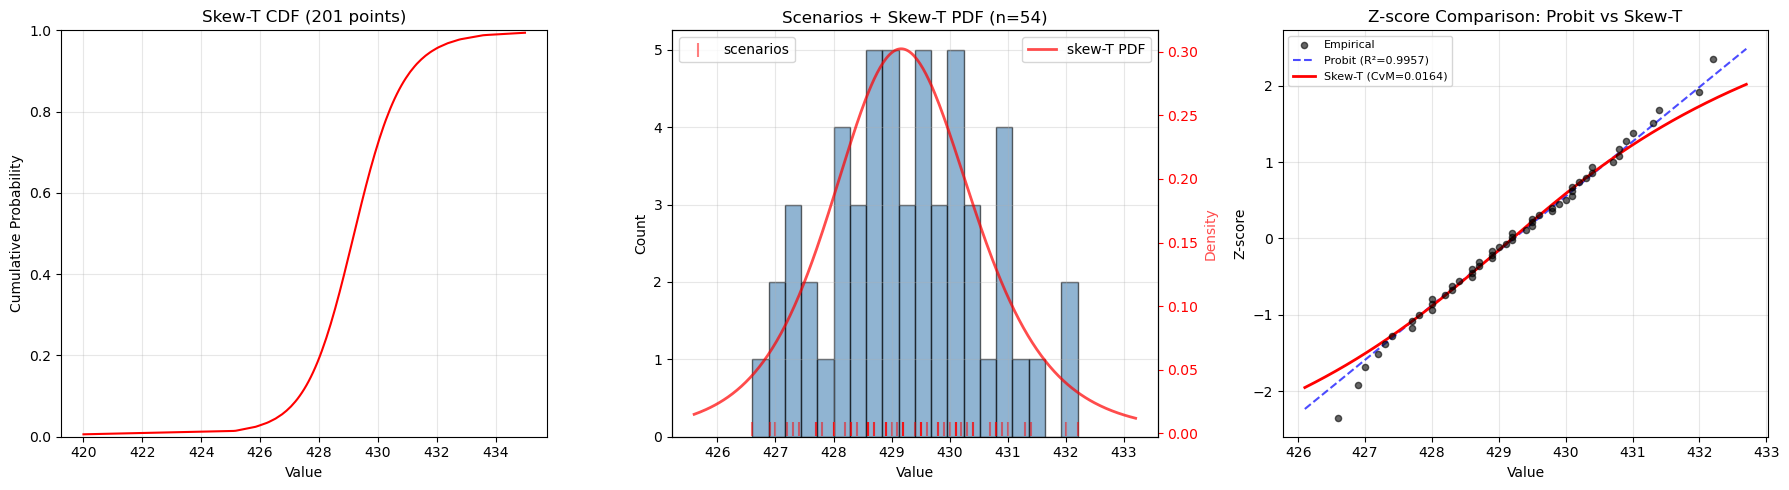


--- Percentile Comparison: Probit vs Skew-T ---
  Pctl      Probit      Skew-T        Diff
  ----      ------      ------        ----
p   1    425.9704    425.1485     -0.8218
p   5    426.9235    426.7430     -0.1805
p  10    427.4317    427.3883     -0.0434
p  25    428.2807    428.2978     +0.0171
p  50    429.2241    429.2000     -0.0241
p  75    430.1674    430.1247     -0.0427
p  90    431.0165    431.0983     +0.0818
p  95    431.5246    431.8079     +0.2833
p  99    432.4778    433.6003     +1.1225


In [14]:
# =====================================================
# Skew-T Visualization
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Subplot 1: Skew-T CDF Curve (201 points) ---
ax1 = axes[0]
ax1.plot(st_cdf_values, st_cdf_201, 'r-', linewidth=1.5)
ax1.set_xlabel('Value')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Skew-T CDF (201 points)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# --- Subplot 2: Scenario Histogram with Skew-T PDF Overlay ---
ax2 = axes[1]
ax2.hist(validated_scenarios, bins=20, alpha=0.6, color='steelblue', edgecolor='black')
ax2.scatter(validated_scenarios, np.zeros(len(validated_scenarios)) + 0.1,
            marker='|', color='red', s=100, alpha=0.5, label='scenarios')
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')
ax2.set_title(f'Scenarios + Skew-T PDF (n={len(validated_scenarios)})')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Overlay skew-T PDF on twin axis
ax2b = ax2.twinx()
x_plot = np.linspace(min(validated_scenarios) - 1, max(validated_scenarios) + 1, 300)
ax2b.plot(x_plot, skewt_pdf(x_plot, st_mu, st_sigma, st_alpha, SKEWT_NU),
          'r-', linewidth=2, alpha=0.7, label='skew-T PDF')
ax2b.set_ylabel('Density', color='red', alpha=0.7)
ax2b.tick_params(axis='y', labelcolor='red', colors='red')
ax2b.legend(loc='upper right')

# --- Subplot 3: Z-score Comparison (Probit vs Skew-T) ---
ax3 = axes[2]
n_sc = len(validated_scenarios)
sc_sorted = np.sort(validated_scenarios)
ecdf_pos = (np.arange(1, n_sc + 1) - 0.5) / n_sc
empirical_z_st = _z_from_pcntl(ecdf_pos)

# Empirical points: value on x-axis, z-score on y-axis
ax3.scatter(sc_sorted, empirical_z_st, s=20, alpha=0.6, color='black', label='Empirical', zorder=5)

# Probit model line (z = (x - intercept) / slope)
x_dense = np.linspace(sc_sorted[0] - 0.5, sc_sorted[-1] + 0.5, 300)
probit_z = (x_dense - intercept) / slope
ax3.plot(x_dense, probit_z, 'b--', linewidth=1.5, alpha=0.7,
         label=f'Probit (R\u00b2={r_squared:.4f})')

# Skew-T model curve (z from inverse CDF)
skewt_cdf_vals = skewt_cdf(x_dense, st_mu, st_sigma, st_alpha, SKEWT_NU)
# Clamp to avoid inf at tails
skewt_cdf_clamped = np.clip(skewt_cdf_vals, 0.001, 0.999)
skewt_z = _z_from_pcntl(skewt_cdf_clamped)
ax3.plot(x_dense, skewt_z, 'r-', linewidth=2,
         label=f'Skew-T (CvM={st_cvm:.4f})')

ax3.set_xlabel('Value')
ax3.set_ylabel('Z-score')
ax3.set_title('Z-score Comparison: Probit vs Skew-T')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Comparison Table ---
print("\n--- Percentile Comparison: Probit vs Skew-T ---")
print(f"{'Pctl':>6}  {'Probit':>10}  {'Skew-T':>10}  {'Diff':>10}")
print(f"{'----':>6}  {'------':>10}  {'------':>10}  {'----':>10}")
for label in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    idx = label - 1
    pv = probit_pairs[idx][1]
    sv = skewt_pairs[idx][1]
    print(f"p{label:>4}  {pv:>10.4f}  {sv:>10.4f}  {sv - pv:>+10.4f}")

In [15]:
# =====================================================
# LLM Reasoning Text
# =====================================================

for i, reasoning in enumerate(all_reasonings, 1):
    print(f"={'=' * 60}")
    print(f"RUN {i}/{len(all_reasonings)}  ({len(reasoning)} chars)")
    print(f"={'=' * 60}")
    print(reasoning)
    print()

RUN 1/6  (3411 chars)
Units for the answer are: parts per million (ppm) of atmospheric CO₂ (monthly average at Mauna Loa Observatory).

## Review some potential outcomes
1. **Time left until the outcome is known:** about **22 days** (until March 2026 monthly mean is finalized).
2. **Outcome if nothing changed (the current value):** late Oct 2025 was reported around **425 ppm** at Mauna Loa (point-in-time, not a March monthly mean).
3. **Outcome if the current trend continued:** recent years show roughly **+2.5 to +3.5 ppm/year** growth; from March 2025 to March 2026 that suggests a March 2026 level around **427 to 429 ppm**, after accounting for the seasonal cycle (rising toward the May peak).
4. **Expectations of experts and markets:** WMO/NOAA commentary implies **continued increases**, with 2023–2024 unusually high growth (~3.5 ppm/yr) and 2025 possibly a bit lower but still elevated.
5. **Volatility history and expectations:** month-to-month values have a strong, predictable **seas